In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 
import sklearn

In [5]:
from keras.api.models import Sequential
from keras.api.layers import Flatten, Dense, Conv2D, MaxPooling2D
from keras.api.utils import to_categorical

Haciendo un ejemplo de clasificación

In [6]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [7]:
x, y = make_blobs(n_samples = 1000, centers = 2, cluster_std = 3, random_state =42)

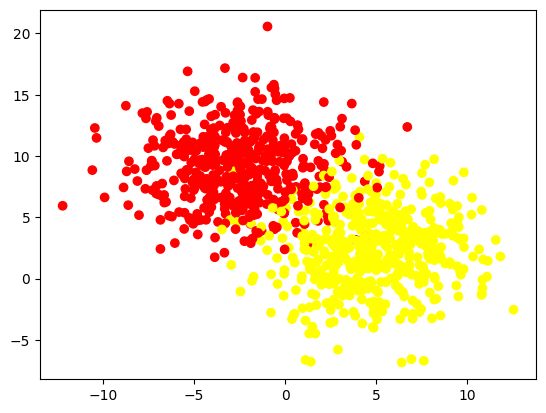

In [8]:
plt.scatter(x[:,0],x[:,1], c = y, cmap = "autumn")

In [9]:
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y, num_classes = 2)

In [10]:
x_train, x_test ,y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [12]:
x_train = x_train.reshape(x_train.shape[0], 1, 2, 1).astype("float32") #Para las redes neuronales convolucionales debe haber 4 canales
#El 4to canal es para el color, se usan imágenes, poner tre' por RGB.

x_test = x_test.reshape(x_test.shape[0], 1, 2, 1).astype("float32")

In [16]:
model = Sequential()

model.add(Conv2D(32, kernel_size = (1,1), activation = "relu", input_shape = (1,2,1))) 
model.add(MaxPooling2D(pool_size = (1,1)))
model.add(Flatten())
model.add(Dense(128, activation = "relu"))

model.add(Dense(2, activation = "softmax")) #capa de salida

C:\Users\Juan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [18]:
model.fit(x_train, y_train, epochs = 10)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7690 - loss: 0.4631
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9365 - loss: 0.1522
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9209 - loss: 0.1817
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9324 - loss: 0.1622
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9455 - loss: 0.1376
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9499 - loss: 0.1321
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9400 - loss: 0.1693
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9518 - loss: 0.1329
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9423 - loss: 0.1424
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9456 - loss: 0.1273


In [19]:
loss, accuracy = model.evaluate(x_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9610 - loss: 0.1003 


In [21]:
print("loss: ", loss)
print("accuracy: ", accuracy)

loss:  0.09401359409093857
accuracy:  0.9599999785423279


In [23]:
from sklearn.metrics import confusion_matrix

In [29]:
y_pred = model.predict(x_test)
y_pred = [np.argmax(x) for x in y_pred]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [30]:
y_pred

[np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.in

In [33]:
y_test = [np.argmax(x) for x in y_test]

In [34]:
confusion_matrix(y_test, y_pred)

array([[101,   2],
       [  6,  91]])